In [15]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import L2
from sklearn.model_selection import train_test_split
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [16]:
import kagglehub
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("uciml/human-activity-recognition-with-smartphones")

train_df = pd.read_csv(os.path.join(path, "train.csv"))
test_df = pd.read_csv(os.path.join(path, "test.csv"))

/Users/naim/Developer/dont-screen-share/ML/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
print(train_df.shape)
print(test_df.shape)

(7352, 563)
(2947, 563)


In [18]:
# Separate features and labels
X = train_df.drop(['Activity', 'subject'], axis=1)
y = train_df['Activity']

X_test = test_df.drop(['Activity', 'subject'], axis=1)
y_test = test_df['Activity']
print(y.unique())

encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(f"X_train shape: {X.shape}")
print(f"X_test shape: {X.shape}")

<StringArray>
[          'STANDING',            'SITTING',             'LAYING',
            'WALKING', 'WALKING_DOWNSTAIRS',   'WALKING_UPSTAIRS']
Length: 6, dtype: str
X_train shape: (7352, 561)
X_test shape: (7352, 561)


In [19]:
X_train, X_cv, y_train, y_cv = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
model = Sequential([
    Dense(516, activation='relu', kernel_regularizer=L2(0.001)),
    Dense(256, activation='relu', kernel_regularizer=L2(0.001)),
    Dense(128, activation='relu', kernel_regularizer=L2(0.001)),
    Dense(64, activation='relu', kernel_regularizer=L2(0.001)),
    Dense(6, activation='linear')
])

In [21]:
model.compile(
    loss=SparseCategoricalCrossentropy(from_logits=True),
    optimizer=Adam(0.001),
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    X_train.to_numpy(), y_train,
    validation_data=(X_cv.to_numpy(), y_cv),
    epochs=20,  # 10 might be a bit short to see convergence
    batch_size=32
)

Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8153 - loss: 1.1107 - val_accuracy: 0.7600 - val_loss: 1.2401
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9255 - loss: 0.6219 - val_accuracy: 0.9558 - val_loss: 0.4934
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9400 - loss: 0.5051 - val_accuracy: 0.8878 - val_loss: 0.6124
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9500 - loss: 0.4429 - val_accuracy: 0.9626 - val_loss: 0.3947
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9520 - loss: 0.3952 - val_accuracy: 0.9456 - val_loss: 0.3776
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9585 - loss: 0.3419 - val_accuracy: 0.9517 - val_loss: 0.3646
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9526 - loss: 0.3366 - val_accuracy: 0.9565 - val_loss: 0.3166
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9563 - loss: 0.3110 - val_accuracy: 0.

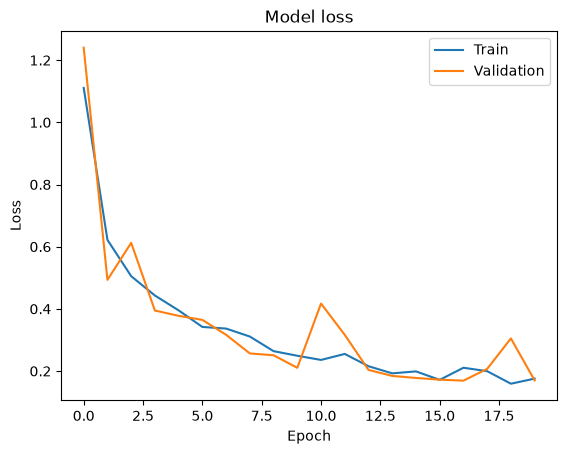

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


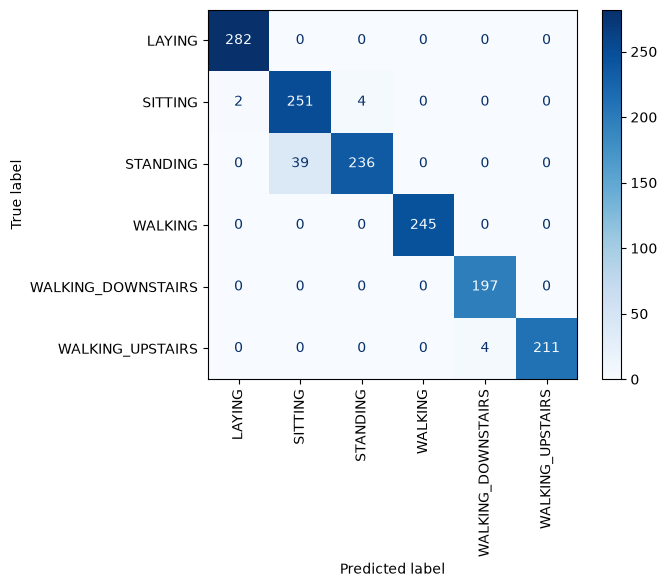

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions on the validation set
logits = model.predict(X_cv.to_numpy())
y_pred = np.argmax(logits, axis=1)

# Generate and display confusion matrix
cm = confusion_matrix(y_cv, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.show()

In [25]:
# Transform test labels using the fitted encoder
y_test_encoded = encoder.transform(y_test)

# Evaluate model performance
test_loss, test_acc = model.evaluate(X_test.to_numpy(), y_test_encoded)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9399 - loss: 0.2489
Test Accuracy: 93.99%
Test Loss: 0.2489
